In [3]:
!pip install -q thop umap-learn


In [4]:
import os
import re
import copy
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    silhouette_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import umap
from thop import profile

2026-04-04 20:29:19.629405: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775334559.828784      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775334559.886279      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775334560.372766      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775334560.372802      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775334560.372805      55 computation_placer.cc:177] computation placer alr

1. SEED + DEVICE

In [5]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


2. CONFIG

In [8]:
CONFIG = {
    "img_size": 224,
    "batch_size_ssl": 64,
    "batch_size_eval": 64,
    "epochs_ssl": 100,
    "lr_ssl": 3e-4,
    "weight_decay": 1e-4,
    "num_workers": 2,
    "train_ratio": 0.8,
    "val_ratio_inside_train": 0.1,
    "save_dir": "/kaggle/working/byol_outputs",
    "ema_decay_base": 0.996,
    "projector_hidden_dim": 2048,
    "projector_out_dim": 256,
    "predictor_hidden_dim": 512,
}
os.makedirs(CONFIG["save_dir"], exist_ok=True)

# ------------------------------------------------------------
# IMPORTANT:
# Put here the folder that contains Original_Images and Augmented_images
# Example:
# DATA_ROOT = "/kaggle/input/processed-rice-varieties/PRBD Microscopic Image of Differe"
# If this exact path does not work, use Kaggle "Copy path"
# ------------------------------------------------------------
DATA_ROOT = "/kaggle/input/datasets/gazimdjubayer/prbd-rice-microscopic-dataset/PRBD Microscopic Image of Different Processed Rice"

print("DATA_ROOT exists:", os.path.exists(DATA_ROOT))
if os.path.exists(DATA_ROOT):
    print("Folders inside root:", os.listdir(DATA_ROOT))

DATA_ROOT exists: True
Folders inside root: ['Original_Images', 'Augmented_images']


3. DATA PREP

In [9]:
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def is_image_file(path):
    return os.path.splitext(path)[1].lower() in VALID_EXTS

def infer_group_id(filepath):
    """
    Keep original image and its augmented versions in the same group
    based on your filename pattern like:
      processed_s20250323_0017
      processed_s20250323_0017_aug_1
      processed_s20250323_0017_aug_2
    """
    name = os.path.splitext(os.path.basename(filepath))[0].lower()

    name = re.sub(r'_aug_\d+$', '', name)
    name = re.sub(r'_aug\d+$', '', name)
    name = re.sub(r'_rot_\d+$', '', name)
    name = re.sub(r'_rot\d+$', '', name)
    name = re.sub(r'_rotate_\d+$', '', name)
    name = re.sub(r'_rotate\d+$', '', name)
    name = re.sub(r'_(flip|hflip|vflip|blur|jitter|crop|noise|sharp|contrast|brightness)$', '', name)

    return name

def build_dataframe(data_root):
    rows = []
    target_folders = ["Original_Images", "Augmented_images"]

    for folder_name in target_folders:
        folder_path = os.path.join(data_root, folder_name)
        if not os.path.exists(folder_path):
            print(f"Warning: {folder_path} not found")
            continue

        class_dirs = [d for d in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, d))]
        class_dirs = sorted(class_dirs)

        for cls_name in class_dirs:
            cls_dir = os.path.join(folder_path, cls_name)
            for root, _, files in os.walk(cls_dir):
                for f in files:
                    path = os.path.join(root, f)
                    if is_image_file(path):
                        rows.append({
                            "filepath": path,
                            "class_name": cls_name,
                            "source_folder": folder_name,
                            "group_id": infer_group_id(path),
                        })

    df = pd.DataFrame(rows)
    if len(df) == 0:
        raise ValueError("No images found. Check DATA_ROOT and folder structure.")

    classes = sorted(df["class_name"].unique())
    class_to_idx = {c: i for i, c in enumerate(classes)}
    df["label"] = df["class_name"].map(class_to_idx)

    return df, classes, class_to_idx

df, classes, class_to_idx = build_dataframe(DATA_ROOT)

print("Total images:", len(df))
print("Classes:", classes)
print(df.head())
print(df["source_folder"].value_counts())

# quick check
print("\nSample group ids:")
print(df.sample(min(10, len(df)), random_state=SEED)[["filepath", "group_id", "class_name", "source_folder"]])

Total images: 10000
Classes: ['Aush', 'BR-28', 'BR-29', 'Beroi', 'Chinigura', 'Ghee Bhog', 'Katari Najir', 'Katari Siddho', 'Miniket', 'Swarna']
                                            filepath class_name  \
0  /kaggle/input/datasets/gazimdjubayer/prbd-rice...       Aush   
1  /kaggle/input/datasets/gazimdjubayer/prbd-rice...       Aush   
2  /kaggle/input/datasets/gazimdjubayer/prbd-rice...       Aush   
3  /kaggle/input/datasets/gazimdjubayer/prbd-rice...       Aush   
4  /kaggle/input/datasets/gazimdjubayer/prbd-rice...       Aush   

     source_folder                  group_id  label  
0  Original_Images  processed_s20250325_0155      0  
1  Original_Images  processed_s20250325_0037      0  
2  Original_Images  processed_s20250325_0215      0  
3  Original_Images  processed_s20250325_0099      0  
4  Original_Images  processed_s20250325_0132      0  
source_folder
Augmented_images    8000
Original_Images     2000
Name: count, dtype: int64

Sample group ids:
                   

4. GROUPED SPLIT

In [10]:
def grouped_train_test_val_split(df, train_ratio=0.8, val_ratio_inside_train=0.1, random_state=42):
    groups = df["group_id"].values
    y = df["label"].values

    gss = GroupShuffleSplit(n_splits=1, train_size=train_ratio, random_state=random_state)
    train_idx, test_idx = next(gss.split(df, y, groups=groups))

    train_df = df.iloc[train_idx].reset_index(drop=True)
    test_df = df.iloc[test_idx].reset_index(drop=True)

    groups_train = train_df["group_id"].values
    y_train = train_df["label"].values

    train_ratio_inside = 1.0 - val_ratio_inside_train
    gss2 = GroupShuffleSplit(n_splits=1, train_size=train_ratio_inside, random_state=random_state)
    tr_idx, val_idx = next(gss2.split(train_df, y_train, groups=groups_train))

    tr_df = train_df.iloc[tr_idx].reset_index(drop=True)
    val_df = train_df.iloc[val_idx].reset_index(drop=True)

    return tr_df, val_df, test_df

train_df, val_df, test_df = grouped_train_test_val_split(
    df,
    train_ratio=CONFIG["train_ratio"],
    val_ratio_inside_train=CONFIG["val_ratio_inside_train"],
    random_state=SEED,
)

print("\nSplit sizes:")
print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

print("Overlap train-val :", len(set(train_df.group_id) & set(val_df.group_id)))
print("Overlap train-test:", len(set(train_df.group_id) & set(test_df.group_id)))
print("Overlap val-test  :", len(set(val_df.group_id) & set(test_df.group_id)))


Split sizes:
Train: 7225
Val  : 790
Test : 1985
Overlap train-val : 0
Overlap train-test: 0
Overlap val-test  : 0


5. TRANSFORMS

In [12]:
class BYOLTransform:
    def __init__(self, size=224):
        self.transform = transforms.Compose([
            transforms.RandomResizedCrop(size=size, scale=(0.6, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomApply([
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)
            ], p=0.8),
            transforms.RandomApply([
                transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5))
            ], p=0.3),
            transforms.RandomGrayscale(p=0.05),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

    def __call__(self, x):
        x1 = self.transform(x)
        x2 = self.transform(x)
        return x1, x2

basic_transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

6. DATASETS + LOADERS

In [13]:
class SSLDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        x1, x2 = self.transform(img)
        return x1, x2

class LabeledDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        x = self.transform(img)
        y = int(row["label"])
        return x, y

ssl_train_dataset = SSLDataset(train_df, BYOLTransform(size=CONFIG["img_size"]))
probe_train_dataset = LabeledDataset(train_df, basic_transform)
probe_val_dataset   = LabeledDataset(val_df, basic_transform)
probe_test_dataset  = LabeledDataset(test_df, basic_transform)

ssl_train_loader = DataLoader(
    ssl_train_dataset,
    batch_size=CONFIG["batch_size_ssl"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
    drop_last=True,
)

probe_train_loader = DataLoader(probe_train_dataset, batch_size=CONFIG["batch_size_eval"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)
probe_val_loader   = DataLoader(probe_val_dataset,   batch_size=CONFIG["batch_size_eval"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)
probe_test_loader  = DataLoader(probe_test_dataset,  batch_size=CONFIG["batch_size_eval"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)

print("SSL train batches:", len(ssl_train_loader))
print("Probe train size :", len(probe_train_dataset))
print("Probe val size   :", len(probe_val_dataset))
print("Probe test size  :", len(probe_test_dataset))

SSL train batches: 112
Probe train size : 7225
Probe val size   : 790
Probe test size  : 1985


7. MODEL

In [14]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)

class EncoderWithProjector(nn.Module):
    def __init__(self, projector_hidden_dim=2048, projector_out_dim=256):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        feat_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()

        self.encoder = backbone
        self.projector = MLP(feat_dim, projector_hidden_dim, projector_out_dim)
        self.feat_dim = feat_dim
        self.out_dim = projector_out_dim

    def forward(self, x):
        feat = self.encoder(x)
        proj = self.projector(feat)
        proj = F.normalize(proj, dim=1)
        return feat, proj

class BYOL(nn.Module):
    def __init__(self):
        super().__init__()
        self.online_net = EncoderWithProjector(
            projector_hidden_dim=CONFIG["projector_hidden_dim"],
            projector_out_dim=CONFIG["projector_out_dim"],
        )
        self.target_net = copy.deepcopy(self.online_net)

        self.predictor = MLP(
            CONFIG["projector_out_dim"],
            CONFIG["predictor_hidden_dim"],
            CONFIG["projector_out_dim"]
        )

        for p in self.target_net.parameters():
            p.requires_grad = False

    @torch.no_grad()
    def update_target(self, m):
        for param_q, param_k in zip(self.online_net.parameters(), self.target_net.parameters()):
            param_k.data = param_k.data * m + param_q.data * (1.0 - m)

    def forward(self, x1, x2):
        # online
        _, q1 = self.online_net(x1)
        _, q2 = self.online_net(x2)
        p1 = self.predictor(q1)
        p2 = self.predictor(q2)
        p1 = F.normalize(p1, dim=1)
        p2 = F.normalize(p2, dim=1)

        # target
        with torch.no_grad():
            _, t1 = self.target_net(x1)
            _, t2 = self.target_net(x2)
            t1 = F.normalize(t1, dim=1)
            t2 = F.normalize(t2, dim=1)

        return p1, p2, t1.detach(), t2.detach()

def byol_loss_fn(p, z):
    return 2 - 2 * (p * z).sum(dim=1).mean()

model = BYOL().to(device)
print(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 116MB/s] 


BYOL(
  (online_net): EncoderWithProjector(
    (encoder): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): 

8. TRAIN SETUP

In [16]:
optimizer = torch.optim.AdamW(
    list(model.online_net.parameters()) + list(model.predictor.parameters()),
    lr=CONFIG["lr_ssl"],
    weight_decay=CONFIG["weight_decay"],
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs_ssl"])
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

9. BYOL PRETRAINING

In [17]:
best_loss = float("inf")
history_ssl = {"epoch": [], "loss": [], "time_sec": []}

print("\nStarting BYOL pretraining...")
for epoch in range(1, CONFIG["epochs_ssl"] + 1):
    model.train()
    running_loss = 0.0
    start_time = time.time()

    # cosine momentum schedule
    m = 1 - (1 - CONFIG["ema_decay_base"]) * (np.cos(np.pi * epoch / CONFIG["epochs_ssl"]) + 1) / 2

    for x1, x2 in ssl_train_loader:
        x1 = x1.to(device, non_blocking=True)
        x2 = x2.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            p1, p2, t1, t2 = model(x1, x2)
            loss = (byol_loss_fn(p1, t2) + byol_loss_fn(p2, t1)) / 2.0

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        model.update_target(m)
        running_loss += loss.item()

    scheduler.step()

    epoch_loss = running_loss / len(ssl_train_loader)
    epoch_time = time.time() - start_time

    history_ssl["epoch"].append(epoch)
    history_ssl["loss"].append(epoch_loss)
    history_ssl["time_sec"].append(epoch_time)

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), os.path.join(CONFIG["save_dir"], "best_byol_model.pth"))
        torch.save(model.online_net.encoder.state_dict(), os.path.join(CONFIG["save_dir"], "best_byol_encoder.pth"))

    print(f"Epoch [{epoch:03d}/{CONFIG['epochs_ssl']}] Loss: {epoch_loss:.4f} | EMA m: {m:.6f} | Time: {epoch_time:.2f}s")

print("Best BYOL loss:", best_loss)


Starting BYOL pretraining...
Epoch [001/100] Loss: 0.7040 | EMA m: 0.996001 | Time: 109.79s
Epoch [002/100] Loss: 0.2496 | EMA m: 0.996004 | Time: 85.43s
Epoch [003/100] Loss: 0.1122 | EMA m: 0.996009 | Time: 84.24s
Epoch [004/100] Loss: 0.0701 | EMA m: 0.996016 | Time: 85.81s
Epoch [005/100] Loss: 0.0509 | EMA m: 0.996025 | Time: 84.92s
Epoch [006/100] Loss: 0.0419 | EMA m: 0.996035 | Time: 85.52s
Epoch [007/100] Loss: 0.0366 | EMA m: 0.996048 | Time: 88.14s
Epoch [008/100] Loss: 0.0328 | EMA m: 0.996063 | Time: 84.97s
Epoch [009/100] Loss: 0.0291 | EMA m: 0.996079 | Time: 84.81s
Epoch [010/100] Loss: 0.0272 | EMA m: 0.996098 | Time: 84.87s
Epoch [011/100] Loss: 0.0264 | EMA m: 0.996118 | Time: 86.70s
Epoch [012/100] Loss: 0.0240 | EMA m: 0.996140 | Time: 85.25s
Epoch [013/100] Loss: 0.0231 | EMA m: 0.996164 | Time: 85.45s
Epoch [014/100] Loss: 0.0223 | EMA m: 0.996190 | Time: 86.34s
Epoch [015/100] Loss: 0.0214 | EMA m: 0.996218 | Time: 89.80s
Epoch [016/100] Loss: 0.0204 | EMA m: 0

10. SSL LOSS CURVE

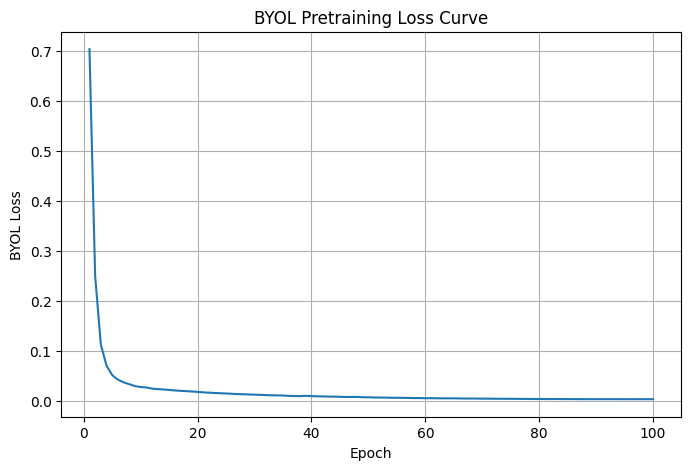

In [18]:
history_df = pd.DataFrame(history_ssl)
history_df.to_csv(os.path.join(CONFIG["save_dir"], "ssl_history.csv"), index=False)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["loss"])
plt.xlabel("Epoch")
plt.ylabel("BYOL Loss")
plt.title("BYOL Pretraining Loss Curve")
plt.grid(True)
plt.show()

11. LOAD BEST ENCODER

In [19]:
model.load_state_dict(torch.load(os.path.join(CONFIG["save_dir"], "best_byol_model.pth"), map_location=device))
encoder = model.online_net.encoder.to(device)
encoder.eval()
print("Best encoder loaded")

Best encoder loaded


12. FEATURE EXTRACTION

In [20]:
@torch.no_grad()
def extract_features(dataloader, encoder):
    encoder.eval()
    all_feats, all_labels = [], []

    for x, y in dataloader:
        x = x.to(device, non_blocking=True)
        feats = encoder(x)
        all_feats.append(feats.cpu().numpy())
        all_labels.append(y.numpy())

    feats = np.concatenate(all_feats, axis=0)
    labels = np.concatenate(all_labels, axis=0)
    return feats, labels

X_train, y_train = extract_features(probe_train_loader, encoder)
X_val,   y_val   = extract_features(probe_val_loader, encoder)
X_test,  y_test  = extract_features(probe_test_loader, encoder)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

X_train: (7225, 2048)
X_val  : (790, 2048)
X_test : (1985, 2048)


13. LINEAR PROBE

In [21]:
probe_clf = LogisticRegression(
    max_iter=2000,
    multi_class="multinomial",
    solver="lbfgs",
    random_state=SEED,
    n_jobs=-1
)

start = time.time()
probe_clf.fit(X_train, y_train)
probe_train_time = time.time() - start

y_pred = probe_clf.predict(X_test)
y_prob = probe_clf.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average="weighted", zero_division=0
)

y_test_bin = label_binarize(y_test, classes=list(range(len(classes))))
roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class="ovr", average="weighted")

print("\n===== Linear Probe Results =====")
print("Accuracy  :", round(acc, 4))
print("Precision :", round(prec, 4))
print("Recall    :", round(rec, 4))
print("F1-score  :", round(f1, 4))
print("ROC-AUC   :", round(roc_auc, 4))
print("Train time:", round(probe_train_time, 2), "sec")


===== Linear Probe Results =====
Accuracy  : 0.9471
Precision : 0.948
Recall    : 0.9471
F1-score  : 0.9471
ROC-AUC   : 0.998
Train time: 4.87 sec


14. REPORTS


Classification Report:

               precision    recall  f1-score   support

         Aush     1.0000    0.9944    0.9972       180
        BR-28     0.8286    0.8700    0.8488       200
        BR-29     0.9231    0.9600    0.9412       200
        Beroi     1.0000    1.0000    1.0000       195
    Chinigura     1.0000    0.9952    0.9976       210
    Ghee Bhog     0.9835    0.9179    0.9496       195
 Katari Najir     0.9205    0.9818    0.9501       165
Katari Siddho     0.9444    0.8947    0.9189       190
      Miniket     0.9692    1.0000    0.9843       220
       Swarna     0.9132    0.8696    0.8909       230

     accuracy                         0.9471      1985
    macro avg     0.9482    0.9484    0.9479      1985
 weighted avg     0.9480    0.9471    0.9471      1985


Per-class Accuracy:
           class  per_class_accuracy
0           Aush            0.994444
1          BR-28            0.870000
2          BR-29            0.960000
3          Beroi            1.000

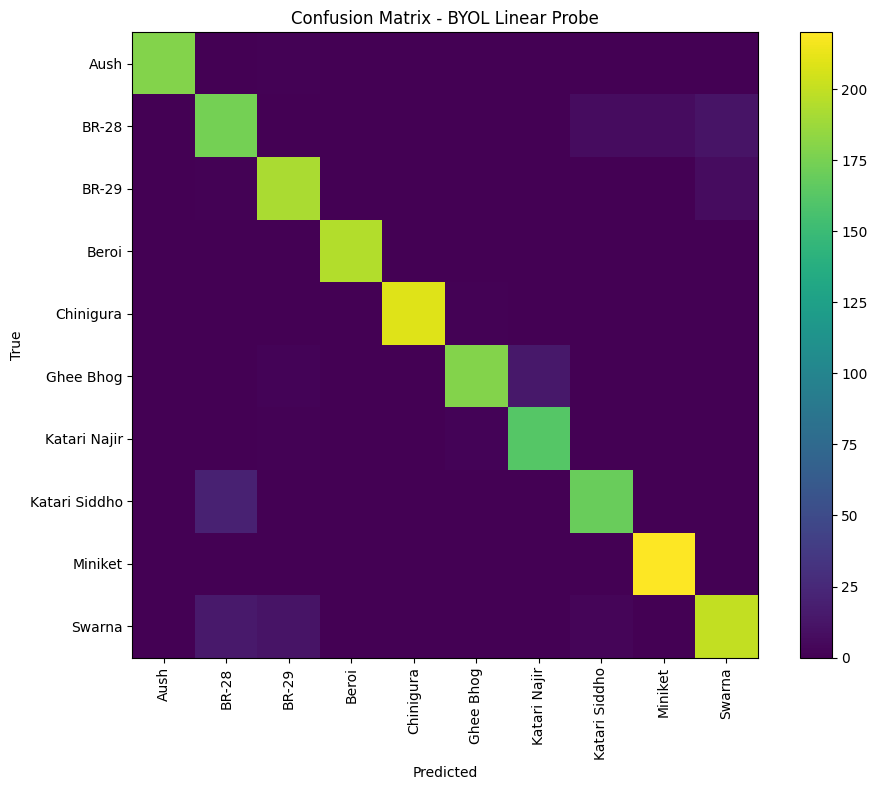

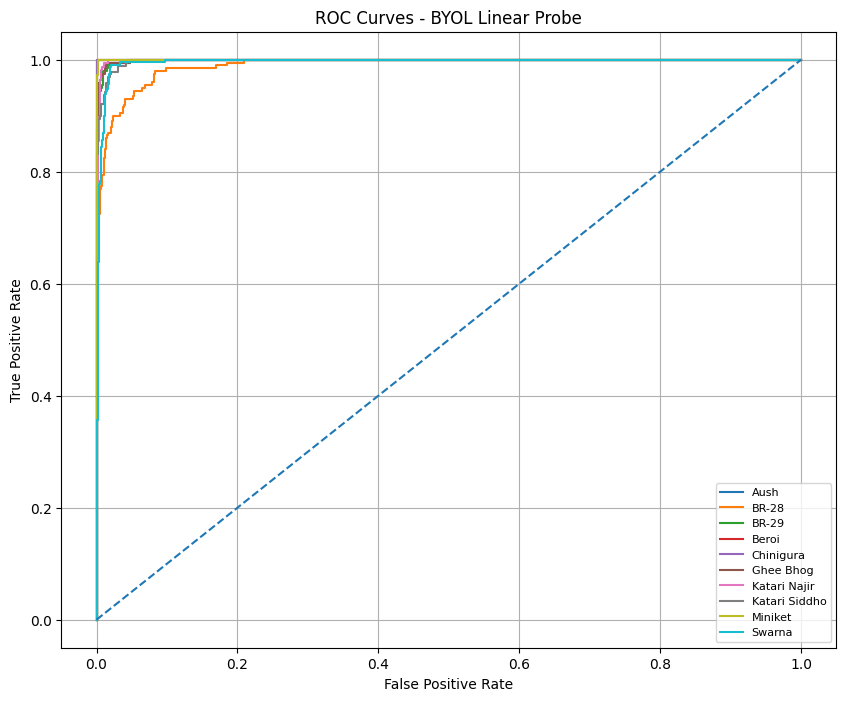

In [22]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=classes, digits=4))

cm = confusion_matrix(y_test, y_pred)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

per_class_df = pd.DataFrame({
    "class": classes,
    "per_class_accuracy": per_class_acc
})
print("\nPer-class Accuracy:")
print(per_class_df)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - BYOL Linear Probe")
plt.colorbar()
plt.xticks(range(len(classes)), classes, rotation=90)
plt.yticks(range(len(classes)), classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
for i, cls_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=cls_name)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - BYOL Linear Probe")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

15. k-NN

In [23]:
print("\n===== k-NN Accuracy =====")
for k in [1, 5, 20]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_knn = knn.predict(X_test)
    acc_knn = accuracy_score(y_test, pred_knn)
    print(f"k={k} -> Accuracy: {acc_knn:.4f}")


===== k-NN Accuracy =====
k=1 -> Accuracy: 0.9078
k=5 -> Accuracy: 0.9204
k=20 -> Accuracy: 0.9350


16. PCA / TSNE / UMAP

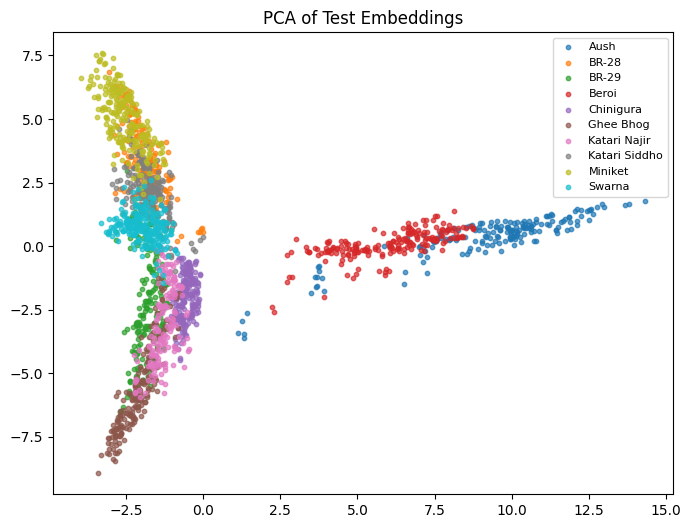

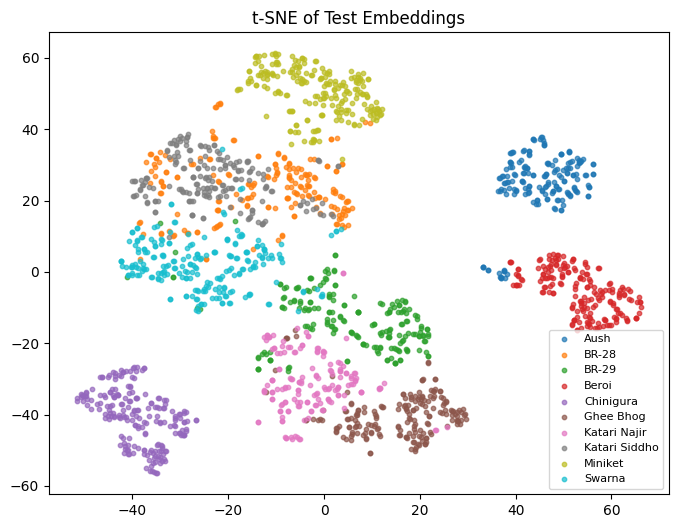

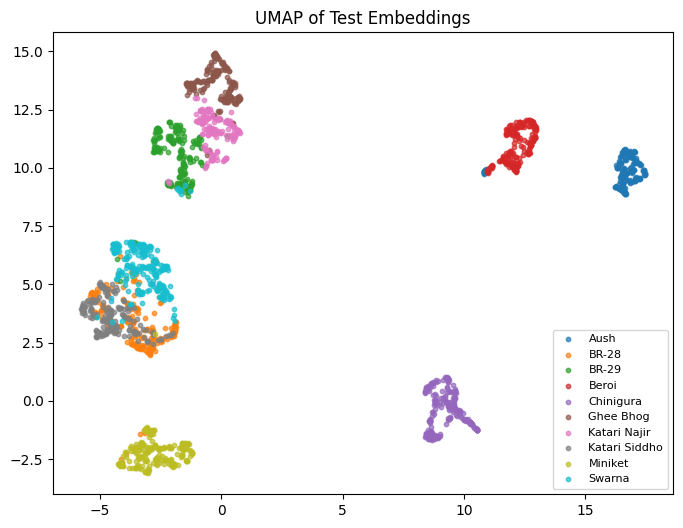

Silhouette Score: 0.0885


In [24]:
max_vis = 2000
if len(X_test) > max_vis:
    idx = np.random.choice(len(X_test), max_vis, replace=False)
    X_vis = X_test[idx]
    y_vis = y_test[idx]
else:
    X_vis = X_test
    y_vis = y_test

pca_2d = PCA(n_components=2, random_state=SEED).fit_transform(X_vis)
plt.figure(figsize=(8, 6))
for i, cls in enumerate(classes):
    m = (y_vis == i)
    plt.scatter(pca_2d[m, 0], pca_2d[m, 1], s=10, alpha=0.7, label=cls)
plt.title("PCA of Test Embeddings")
plt.legend(fontsize=8)
plt.show()

tsne_2d = TSNE(n_components=2, random_state=SEED, perplexity=30, init="pca").fit_transform(X_vis)
plt.figure(figsize=(8, 6))
for i, cls in enumerate(classes):
    m = (y_vis == i)
    plt.scatter(tsne_2d[m, 0], tsne_2d[m, 1], s=10, alpha=0.7, label=cls)
plt.title("t-SNE of Test Embeddings")
plt.legend(fontsize=8)
plt.show()

umap_2d = umap.UMAP(n_components=2, random_state=SEED).fit_transform(X_vis)
plt.figure(figsize=(8, 6))
for i, cls in enumerate(classes):
    m = (y_vis == i)
    plt.scatter(umap_2d[m, 0], umap_2d[m, 1], s=10, alpha=0.7, label=cls)
plt.title("UMAP of Test Embeddings")
plt.legend(fontsize=8)
plt.show()

sil_score = silhouette_score(X_vis, y_vis)
print("Silhouette Score:", round(sil_score, 4))

17. LABEL EFFICIENCY


===== Label Efficiency =====
1% labels -> Accuracy: 0.8196
5% labels -> Accuracy: 0.9305
10% labels -> Accuracy: 0.9320
25% labels -> Accuracy: 0.9431
50% labels -> Accuracy: 0.9395


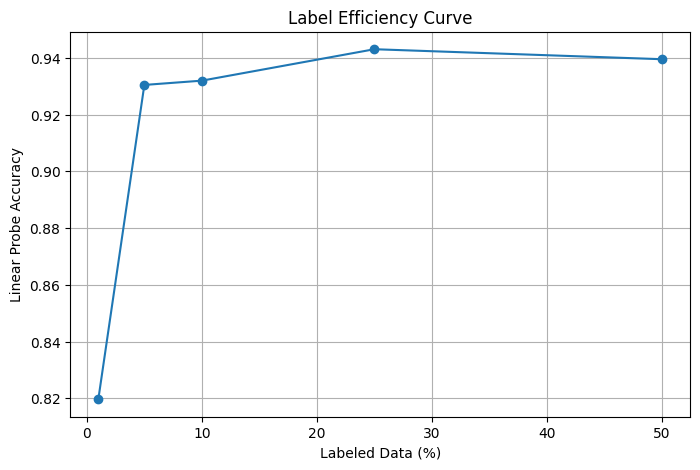

In [25]:
fractions = [0.01, 0.05, 0.10, 0.25, 0.50]
label_eff_results = []

print("\n===== Label Efficiency =====")
for frac in fractions:
    sampled_idx = []

    for c in np.unique(y_train):
        c_idx = np.where(y_train == c)[0]
        n_take = max(1, int(len(c_idx) * frac))
        chosen = np.random.choice(c_idx, n_take, replace=False)
        sampled_idx.extend(chosen.tolist())

    sampled_idx = np.array(sampled_idx)

    clf_frac = LogisticRegression(
        max_iter=2000,
        multi_class="multinomial",
        solver="lbfgs",
        random_state=SEED,
        n_jobs=-1
    )
    clf_frac.fit(X_train[sampled_idx], y_train[sampled_idx])
    pred_frac = clf_frac.predict(X_test)
    acc_frac = accuracy_score(y_test, pred_frac)

    label_eff_results.append({
        "fraction": frac,
        "accuracy": acc_frac,
        "n_samples": len(sampled_idx)
    })

    print(f"{int(frac*100)}% labels -> Accuracy: {acc_frac:.4f}")

label_eff_df = pd.DataFrame(label_eff_results)

plt.figure(figsize=(8, 5))
plt.plot(label_eff_df["fraction"] * 100, label_eff_df["accuracy"], marker="o")
plt.xlabel("Labeled Data (%)")
plt.ylabel("Linear Probe Accuracy")
plt.title("Label Efficiency Curve")
plt.grid(True)
plt.show()

18. GFLOPs

In [26]:
dummy = torch.randn(1, 3, CONFIG["img_size"], CONFIG["img_size"]).to(device)
macs, params = profile(encoder, inputs=(dummy,), verbose=False)
gflops = (2 * macs) / 1e9

print(f"GFLOPs per inference @ {CONFIG['img_size']}x{CONFIG['img_size']}: {gflops:.4f}")
print(f"Params: {params/1e6:.2f}M")

GFLOPs per inference @ 224x224: 8.2634
Params: 23.51M


19. SAVE SUMMARY

In [27]:
summary = {
    "method": "BYOL",
    "backbone": "ResNet50",
    "split": f"{int(CONFIG['train_ratio']*100)}:{int((1-CONFIG['train_ratio'])*100)}",
    "epochs_ssl": CONFIG["epochs_ssl"],
    "img_size": CONFIG["img_size"],
    "accuracy": acc,
    "precision_weighted": prec,
    "recall_weighted": rec,
    "f1_weighted": f1,
    "roc_auc_weighted_ovr": roc_auc,
    "linear_probe_train_time_sec": probe_train_time,
    "silhouette_score": sil_score,
    "gflops": gflops,
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(os.path.join(CONFIG["save_dir"], "final_summary.csv"), index=False)
per_class_df.to_csv(os.path.join(CONFIG["save_dir"], "per_class_accuracy.csv"), index=False)
label_eff_df.to_csv(os.path.join(CONFIG["save_dir"], "label_efficiency.csv"), index=False)

print("\nSaved in:", CONFIG["save_dir"])
print(summary_df)


Saved in: /kaggle/working/byol_outputs
  method  backbone  split  epochs_ssl  img_size  accuracy  precision_weighted  \
0   BYOL  ResNet50  80:19         100       224  0.947103            0.947958   

   recall_weighted  f1_weighted  roc_auc_weighted_ovr  \
0         0.947103     0.947096              0.998036   

   linear_probe_train_time_sec  silhouette_score    gflops  
0                     4.868532          0.088531  8.263389  
